# Online Retail II — Exploratory Data Analysis (EDA)

**Objective:** Explore real transaction data (2009–2011) from a UK-based online retailer to understand customer purchase behavior, top-selling products, and country-wise revenue performance — before building a recommendation system.

**Dataset:** [Online Retail II — UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Online+Retail+II)


**Author:** Kiran Aslam


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Load the Dataset

The official UCI file `online_retail_II.xlsx` has **two sheets**: `Year 2009-2010` and `Year 2010-2011`.


In [9]:
FILE_PATH = "Data/online_retail_II.xlsx"  

def load_online_retail(path):
    if path.endswith(".xlsx"):
        sheets = pd.read_excel(path, sheet_name=None)  # reads all sheets into a dict
        df_ = pd.concat(sheets.values(), ignore_index=True)
    else:
        df_ = pd.read_csv(path, encoding="ISO-8859-1")
    return df_

df = load_online_retail(FILE_PATH)

# Standardize column names (handles both 'Customer ID' and 'CustomerID' variants)
df.columns = [c.strip() for c in df.columns]
rename_map = {"Customer ID": "CustomerID", "UnitPrice": "Price"}
df.rename(columns=rename_map, inplace=True)
for col in ["Invoice", "StockCode"]:
    if col in df.columns:
        df[col] = df[col].astype(str)

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## 3. Basic Dataset Information

In [10]:
print(f"Shape of dataset: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Column names:")
print(list(df.columns), "\n")
print("Data types:")
print(df.dtypes)


Shape of dataset: 1,067,371 rows x 8 columns

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country'] 

Data types:
Invoice                   str
StockCode                 str
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
CustomerID            float64
Country                   str
dtype: object


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(1), str(3)
memory usage: 65.1+ MB


In [12]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"1,067,371.00",NaN,NaN,NaN,9.94,"-80,995.00",1.00,3.00,10.00,"80,995.00",172.71
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394029,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,"1,067,371.00",NaN,NaN,NaN,4.65,"-53,594.36",1.25,2.10,4.15,"38,970.00",123.55
CustomerID,"824,364.00",NaN,NaN,NaN,"15,324.64","12,346.00","13,975.00","15,255.00","16,797.00","18,287.00","1,697.46"
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Missing Values

I report missing values per column — **no rows are removed**. In this dataset, `CustomerID` and
`Description` are typically the columns with missing data, which matters a lot for a future



In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
}).sort_values("Missing Count", ascending=False)

missing_report = missing_report[missing_report["Missing Count"] > 0]
print("Missing Values Report:")
missing_report


Missing Values Report:


,Missing Count,Missing %
CustomerID,243007,22.77
Description,4382,0.41


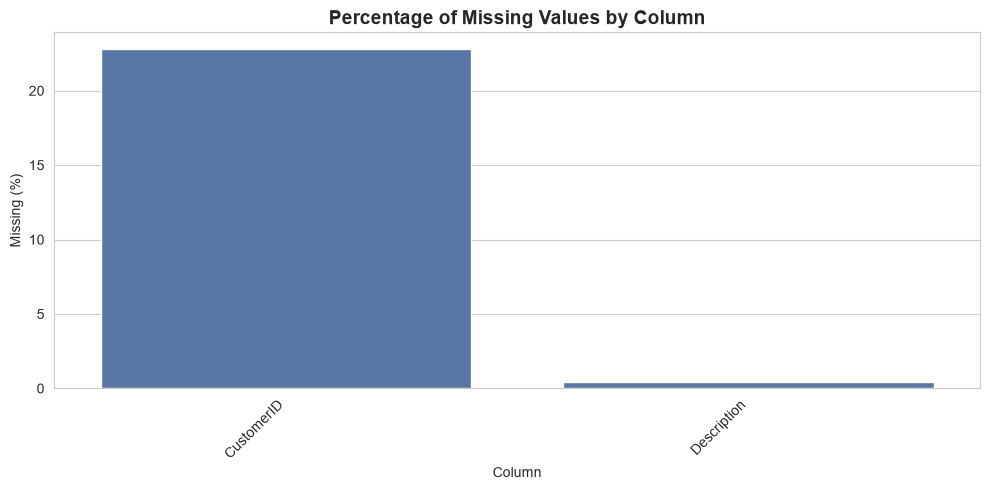

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_report.index, y=missing_report["Missing %"], color="#4C72B0")
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 5. Duplicate Rows

In [15]:
duplicate_count = df.duplicated().sum()
duplicate_pct = (duplicate_count / len(df)) * 100

print(f"Total duplicate rows: {duplicate_count:,} ({duplicate_pct:.2f}% of dataset)")
print("\nSample duplicate rows:")
df[df.duplicated(keep=False)].sort_values(
    by=df.columns[0],
    key=lambda col: col.astype(str)
).head(10)

Total duplicate rows: 34,335 (3.22% of dataset)

Sample duplicate rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,"16,329.00",United Kingdom
388,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,"16,329.00",United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom


## 6. Add Revenue Column (for analysis only)

`Revenue = Quantity x Price`. This is an **added** column, not a modification/removal of existing data.


In [16]:
df["Revenue"] = df["Quantity"] * df["Price"]
df[["Quantity", "Price", "Revenue"]].describe()


,Quantity,Price,Revenue
count,"1,067,371.00","1,067,371.00","1,067,371.00"
mean,9.94,4.65,18.07
std,172.71,123.55,292.42
min,"-80,995.00","-53,594.36","-168,469.60"
25%,1.00,1.25,3.75
50%,3.00,2.10,9.90
75%,10.00,4.15,17.70
max,"80,995.00","38,970.00","168,469.60"


## 7. Top 10 Best-Selling Products — by Quantity

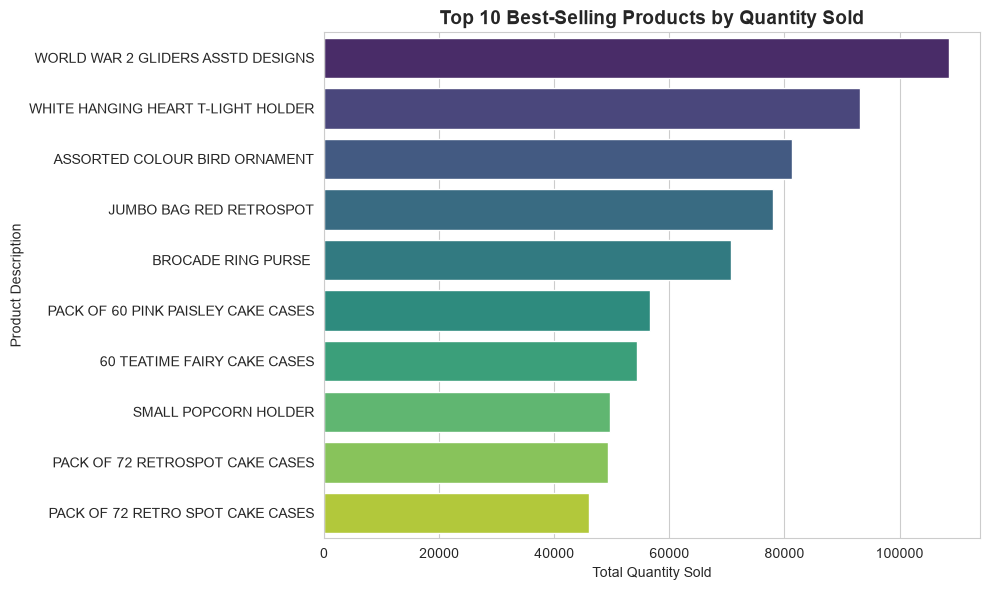

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108545
WHITE HANGING HEART T-LIGHT HOLDER     93050
ASSORTED COLOUR BIRD ORNAMENT          81306
JUMBO BAG RED RETROSPOT                78090
BROCADE RING PURSE                     70700
PACK OF 60 PINK PAISLEY CAKE CASES     56575
60 TEATIME FAIRY CAKE CASES            54366
SMALL POPCORN HOLDER                   49616
PACK OF 72 RETROSPOT CAKE CASES        49344
PACK OF 72 RETRO SPOT CAKE CASES       46106
Name: Quantity, dtype: int64

In [17]:
top10_qty = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_qty.values, y=top10_qty.index, palette="viridis")
plt.title("Top 10 Best-Selling Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()

top10_qty


## 8. Top 10 Best-Selling Products — by Revenue

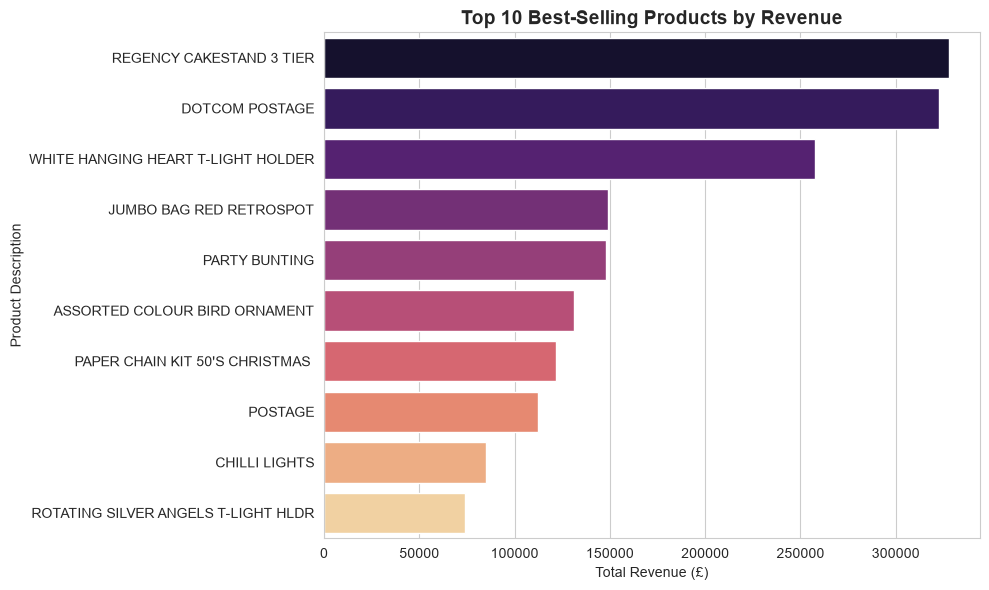

Description
REGENCY CAKESTAND 3 TIER              327,813.65
DOTCOM POSTAGE                        322,647.47
WHITE HANGING HEART T-LIGHT HOLDER    257,533.90
JUMBO BAG RED RETROSPOT               148,800.64
PARTY BUNTING                         147,948.50
ASSORTED COLOUR BIRD ORNAMENT         131,413.85
PAPER CHAIN KIT 50'S CHRISTMAS        121,662.14
POSTAGE                               112,341.00
CHILLI LIGHTS                          84,854.16
ROTATING SILVER ANGELS T-LIGHT HLDR    73,814.72
Name: Revenue, dtype: float64

In [18]:
top10_rev = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_rev.values, y=top10_rev.index, palette="magma")
plt.title("Top 10 Best-Selling Products by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()

top10_rev


## 9. Sales Performance by Country

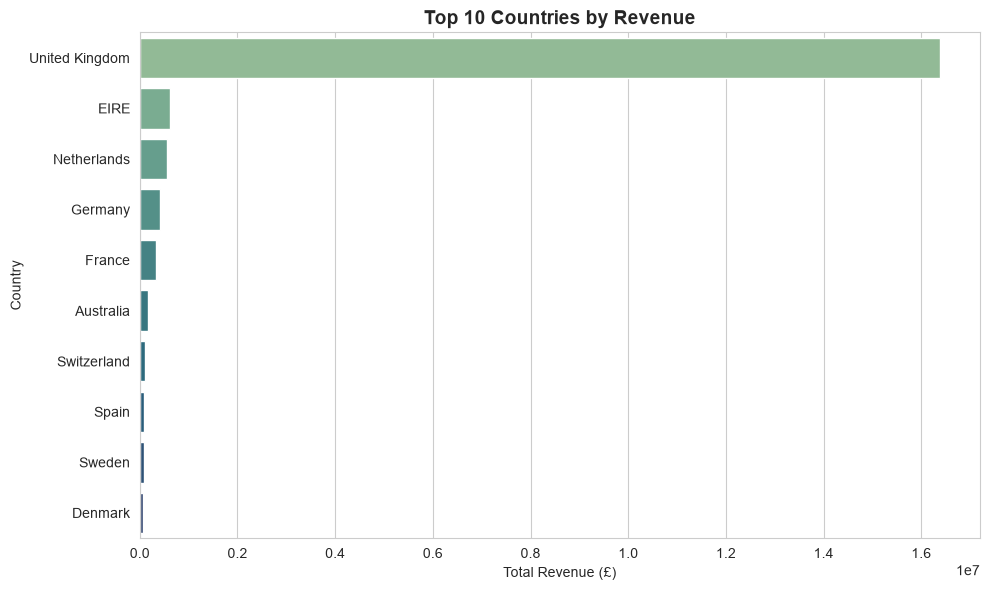

,Total_Revenue,Total_Orders,Total_Quantity
Country,,,
United Kingdom,"16,382,583.90",49108,8692875
EIRE,"615,519.55",806,331341
Netherlands,"548,524.95",250,381951
Germany,"417,988.56",1095,224581
France,"328,191.80",746,184952
Australia,"167,129.07",117,103706
Switzerland,"99,728.76",123,52378
Spain,"91,859.48",188,45156
Sweden,"87,809.42",129,87875


In [19]:
country_perf = (
    df.groupby("Country")
    .agg(Total_Revenue=("Revenue", "sum"),
         Total_Orders=("Invoice", "nunique"),
         Total_Quantity=("Quantity", "sum"))
    .sort_values("Total_Revenue", ascending=False)
)

top10_country = country_perf.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_country["Total_Revenue"], y=top10_country.index, palette="crest")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

top10_country


## 10. Revenue Over Time — Monthly Trend

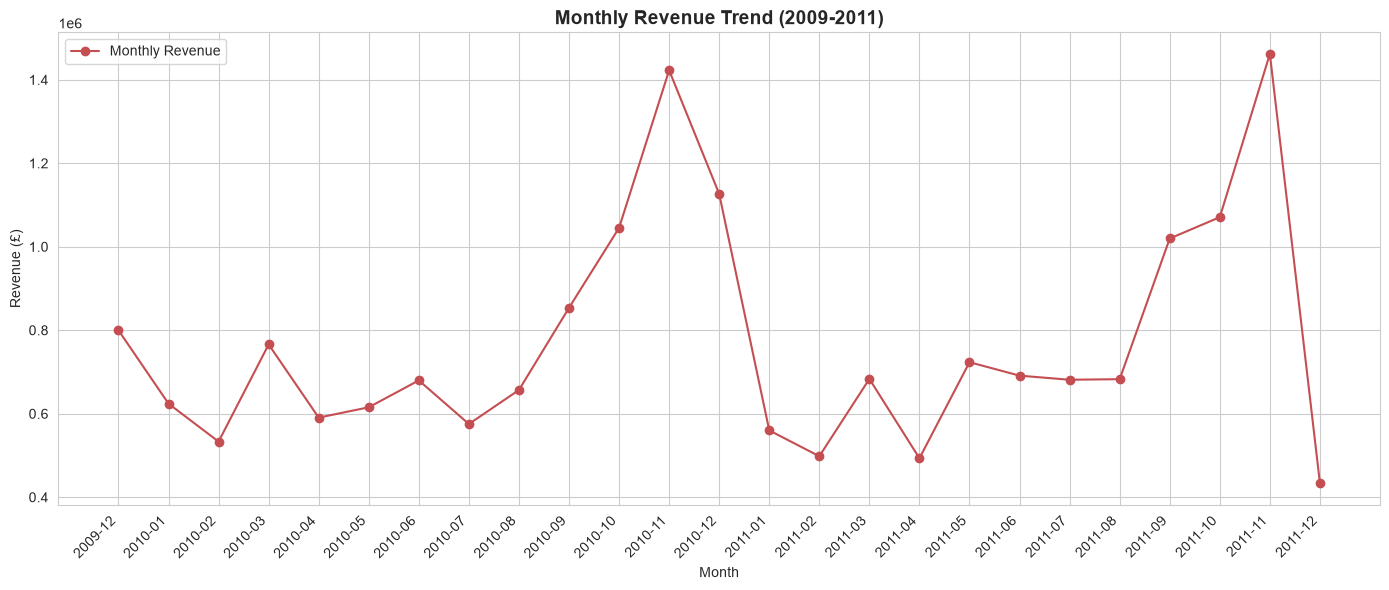

In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("InvoiceMonth")["Revenue"].sum().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="#C44E52", label="Monthly Revenue")
plt.title("Monthly Revenue Trend (2009-2011)")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Correlation Heatmap

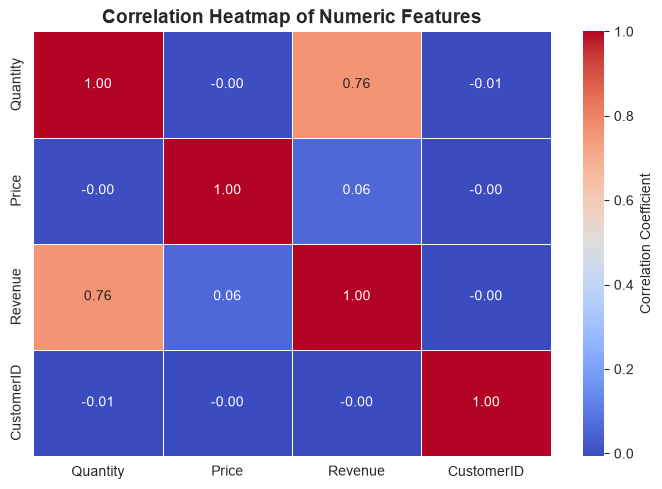

In [21]:
numeric_cols = ["Quantity", "Price", "Revenue"]
if "CustomerID" in df.columns:
    numeric_cols.append("CustomerID")

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={"label": "Correlation Coefficient"})
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


## 12. Outlier Detection — Box Plots

`Quantity` and `Price` are checked for outliers. This dataset naturally contains extreme values
(bulk wholesale orders, cancellations with negative quantity)


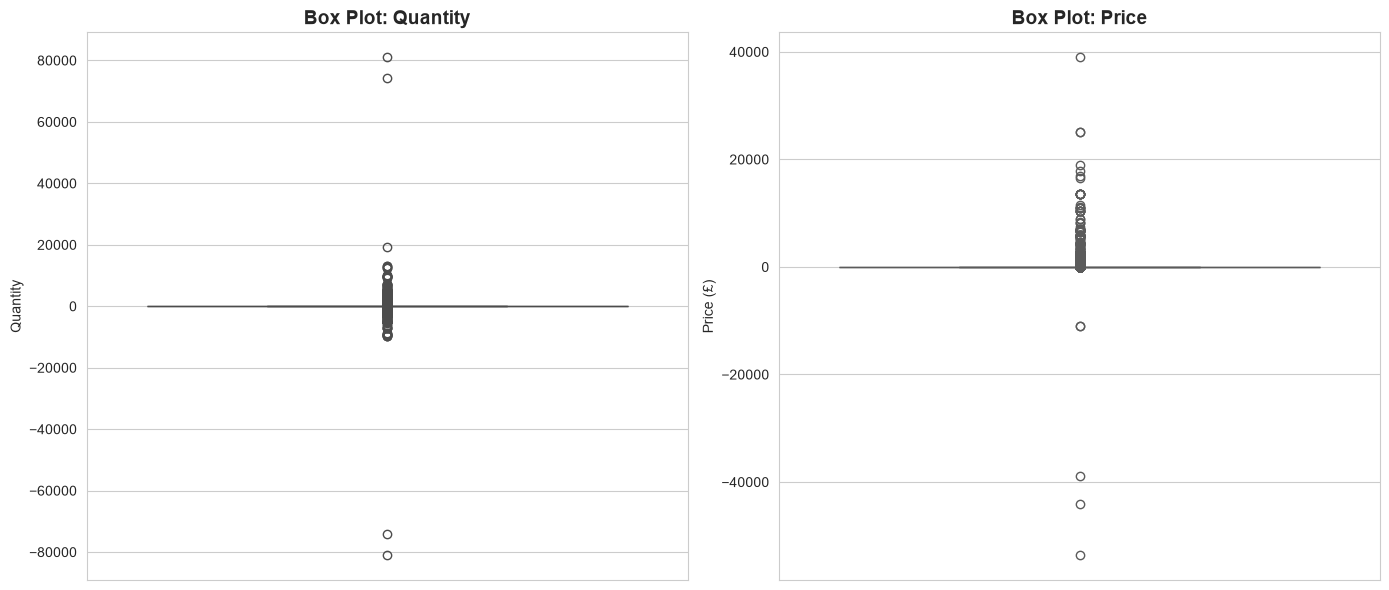

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(y=df["Quantity"], ax=axes[0], color="#55A868")
axes[0].set_title("Box Plot: Quantity")
axes[0].set_ylabel("Quantity")

sns.boxplot(y=df["Price"], ax=axes[1], color="#DD8452")
axes[1].set_title("Box Plot: Price")
axes[1].set_ylabel("Price (£)")

plt.tight_layout()
plt.show()


In [23]:
# Quantify outliers using the IQR method (for reporting purposes only )
def iqr_outlier_summary(series, name):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: {len(outliers):,} outliers ({len(outliers)/len(series)*100:.2f}%) "
          f"| valid range: [{lower:.2f}, {upper:.2f}]")

iqr_outlier_summary(df["Quantity"], "Quantity")
iqr_outlier_summary(df["Price"], "Price")


Quantity: 116,489 outliers (10.91%) | valid range: [-12.50, 23.50]
Price: 68,105 outliers (6.38%) | valid range: [-3.10, 8.50]


In [25]:
# Compute business insight values from the current notebook state
top_rev_product = top10_rev.idxmax()
top_rev_value = top10_rev.max()
top_qty_product = top10_qty.idxmax()
top_qty_value = top10_qty.max()
peak_month = monthly_revenue.idxmax()
peak_month_value = monthly_revenue.max()
top_country = top10_country.index[0]
top_country_value = top10_country.iloc[0]['Total_Revenue']
top_country_pct = top_country_value / country_perf['Total_Revenue'].sum() * 100
customerid_missing_pct = missing_report.loc['CustomerID', 'Missing %'] if 'CustomerID' in missing_report.index else 0.0
Q1_q, Q3_q = df['Quantity'].quantile([0.25, 0.75])
IQR_q = Q3_q - Q1_q
lower_q, upper_q = Q1_q - 1.5 * IQR_q, Q3_q + 1.5 * IQR_q
quantity_outlier_pct = ((df['Quantity'] < lower_q) | (df['Quantity'] > upper_q)).mean() * 100
Q1_p, Q3_p = df['Price'].quantile([0.25, 0.75])
IQR_p = Q3_p - Q1_p
lower_p, upper_p = Q1_p - 1.5 * IQR_p, Q3_p + 1.5 * IQR_p
price_outlier_pct = ((df['Price'] < lower_p) | (df['Price'] > upper_p)).mean() * 100
q_r_corr = corr_matrix.loc['Quantity', 'Revenue']
p_r_corr = corr_matrix.loc['Price', 'Revenue']
print(f'top_rev_product|{top_rev_product}')
print(f'top_rev_value|{top_rev_value:.2f}')
print(f'top_qty_product|{top_qty_product}')
print(f'top_qty_value|{top_qty_value:.0f}')
print(f'peak_month|{peak_month}')
print(f'peak_month_value|{peak_month_value:.2f}')
print(f'top_country|{top_country}')
print(f'top_country_value|{top_country_value:.2f}')
print(f'top_country_pct|{top_country_pct:.2f}')
print(f'customerid_missing_pct|{customerid_missing_pct:.2f}')
print(f'quantity_outlier_pct|{quantity_outlier_pct:.2f}')
print(f'price_outlier_pct|{price_outlier_pct:.2f}')
print(f'q_r_corr|{q_r_corr:.2f}')
print(f'p_r_corr|{p_r_corr:.2f}')


top_rev_product|REGENCY CAKESTAND 3 TIER
top_rev_value|327813.65
top_qty_product|WORLD WAR 2 GLIDERS ASSTD DESIGNS
top_qty_value|108545
peak_month|2011-11
peak_month_value|1461756.25
top_country|United Kingdom
top_country_value|16382583.90
top_country_pct|84.94
customerid_missing_pct|22.77
quantity_outlier_pct|10.91
price_outlier_pct|6.38
q_r_corr|0.76
p_r_corr|0.06


## 13. Business Insights

1. **Revenue and volume leaders aren't the same product.** "WORLD WAR 2 GLIDERS ASSTD DESIGNS" sold the most units (108,545), but "REGENCY CAKESTAND 3 TIER" generated the highest revenue (£327,813.65) despite not appearing in the top 10 by quantity at all. This tells the business that a recommendation engine optimized purely for "most purchased" would completely miss the products that actually drive the most money.

2. **The business is almost entirely UK-dependent.** United Kingdom alone contributed £16,382,583.90 in revenue — about 85% of total revenue across all 43 countries in the dataset. The next closest market, EIRE, brought in only £615,519.55. This heavy concentration is a risk: any slowdown in the UK market would hit the business far harder than a geographically diversified retailer, and it suggests real growth potential in underdeveloped markets like Germany, France, and the Netherlands.

3. **Revenue is strongly seasonal, peaking around November.** Monthly revenue climbs steadily from mid-year and peaks sharply in November both years (£1.42M in Nov 2010, £1.46M in Nov 2011) before dropping — consistent with pre-Christmas gift buying. Inventory planning, staffing, and marketing budget should be weighted toward Q4, especially October–November, rather than spread evenly across the year.

4. **Nearly a quarter of transactions can't be tied to a customer.** CustomerID is missing in 22.77% of all rows (243,007 transactions). Since a recommendation system depends entirely on linking purchases to a specific customer, this is a significant blind spot — almost 1 in 4 transactions currently can't feed into personalized recommendations at all, and this gap needs to be understood (guest checkouts? data entry issue?) before modeling begins.

5. **Outliers are business behavior, not bad data.** Quantity ranges from -80,995 to +80,995, and Price ranges from -£53,594.36 to +£38,970 — extreme values on both ends. These aren't random errors; they reflect large wholesale/bulk orders and their corresponding cancellations (negative quantities mirror positive ones almost exactly). This matters for later modeling: naively removing "outliers" by a standard IQR cutoff would strip out legitimate high-value B2B transactions along with genuine noise.

6. **Quantity, not price, drives revenue.** The correlation heatmap shows Quantity and Revenue are strongly correlated (0.76), while Price and Revenue are barely correlated (0.06). This suggests revenue in this business is driven much more by how much customers buy than by how expensive individual items are — reinforcing that volume-based promotions (bundles, multi-buy discounts) may be more effective than price-based ones.

7. **Duplicate records exist but are limited.** 34,335 rows (3.22% of the dataset) are exact duplicates. This is a moderate but non-trivial amount — while the task requires keeping them for this observation-only stage, they should be flagged for cleaning before any modeling step, since duplicate transactions could artificially inflate perceived purchase frequency for certain products or customers.